## Import necessary packages 

In [1]:
# Python modules 
import numpy as np
# import matplotlib
import matplotlib.pyplot as plt
# matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import pandas as pd
import importlib
from numpy import loadtxt
# from matplotlib import gridspec # for the contour plots
from cvxopt import matrix, solvers

# pyDRTtools' modules
import pyDRTtools
import pyDRTtools.basics as basics # pyDRTtools functions
# import pyDRTtools.GUI as UI

import os
from glob import glob





Initializing pyDRTtools from C:\Users\Herman\anaconda3\lib\site-packages
['', 'C:\\Users\\Herman\\psi4conda\\Lib\\site-packages', 'C:\\Users\\Herman\\psi4conda\\Lib\\site-packages\\_plotly_utils', 'C:\\Users\\Herman\\.spyder-py3', 'C:\\Users\\Herman\\anaconda3\\python38.zip', 'C:\\Users\\Herman\\anaconda3\\DLLs', 'C:\\Users\\Herman\\anaconda3\\lib', 'C:\\Users\\Herman\\anaconda3', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\win32', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\win32\\lib', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\Pythonwin', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\setuptools\\_vendor']
Imported basics
Imported BHT
Imported HMC
Imported nearest_PD
Imported parameter_selection
Imported peak_analysis
Imported runs
Contents of pyDRTtools package: ['basics', 'parameter_selection', 'peak_analysis', 'HMC', 'runs', 'nearest_PD']


In [69]:
## for nice plot
# options for the plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
#%matplotlib inline

#### 2.1 Load and analyze many EIS spectra concomitantly

In [2]:
   
def get_header_lines(filepath):
    with open(filepath, "r", encoding="latin-1") as f:
        # Skip first line, read second
        f.readline()  
        line2 = f.readline().strip()
    # line2 looks like: "Nb header lines : 76"
    # split by ":" and take the right part
    try:
        n_header = int(line2.split(":")[1])
    except Exception:
        raise ValueError(f"Could not parse header line: {line2}")
    return n_header

def drt_to_impedance(tau, gamma, freq, R_inf=0.0, L = 0):
    """
    Convert DRT spectrum to complex impedance.

    Parameters
    ----------
    tau : array_like
        Relaxation times (s), log-spaced
    gamma : array_like
        DRT values (Ohm)
    freq : array_like
        Frequencies (Hz)
    R_inf : float, optional
        High-frequency resistance (Ohm)

    Returns
    -------
    Z : ndarray
        Complex impedance at each frequency
    """
    omega = 2 * np.pi * freq
    ln_tau = np.log(tau)

    Z = np.zeros(len(freq), dtype=complex)

    for i, w in enumerate(omega):
        kernel = gamma / (1 + 1j * w * tau)
        Z[i] = R_inf + 1j*w*L+ np.trapz(kernel, ln_tau)

    return Z


In [3]:
s295 = {'name' : '295', 'comp' : '30 Ir 30 C'}
MEA = [s295]

for mea in MEA:
    mea['folder']= glob(os.path.join(r'C:/Users/Herman/Desktop/WE/testDRT/'))[0]
    # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2024_new_naming/'+'*'+mea['name']+'*/'))[0]
    # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
    # folder = r"C:/Users/Herman/Desktop/"
    print(mea['folder'])
    # mea['files'] =  glob(os.path.join(mea['folder'],'*batch2_3_batch1_interruptions_*'+'*PEIS_C01.mpt'))
    mea['files'] =  glob(os.path.join(mea['folder']+'spectra/','*3*'+'.txt'))
    print(mea['files'])

C:/Users/Herman/Desktop/WE/testDRT/
['C:/Users/Herman/Desktop/WE/testDRT/spectra\\spectrum3.txt', 'C:/Users/Herman/Desktop/WE/testDRT/spectra\\spectrum3new.txt']


In [4]:
shape_control = 'FWHM Coefficient'
coeff = 0.5
# order of the derivative for the differentiation matrix M ('1st', '2nd')
# rbf_type = 'Piecewise Linear'
rbf_type = 'Gaussian'
# rbf_type = 'C0 Matern'
# rbf_type = 'C2 Matern'
# rbf_type = 'C4 Matern'
# rbf_type = 'C6 Matern'
# rbf_type = 'Inverse Quadratic'

In [5]:
cv_type = 'GCV'
# cv_type = 'mGCV'
# cv_type = 'rGCV'
# cv_type = 'LC'
# cv_type = 'kf'
# cv_type = 're-im'

In [6]:
for file in mea['files']:
    freq_vec_old = [1,2]
    print(file)
#     print((n-n%3)/3)
#     file = s244['files'][int((n-n%3)/3)]
    # file = s244['files'][n]
    skip_rows = get_header_lines(file)
    with open(file, encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,30),delimiter = '\t')
        
        
    unique_vals = np.unique(df["cycle number"].values)
    # groups = [data[df["cycle number"].values == val] for val in unique_vals]
    
    # R_inf_DRT_list = []
    # L_0_DRT_list = []
    DRT_list = []
    # Z_DRT_list = [0]*len(unique_vals)
    # Z_exp_list = [0]*len(unique_vals)
    Z_exp_list = []
    freq_list = []
    log_tau_list = []
    lambda_value = 0.02
    rows = []
    
    for val in unique_vals:
        freq_vec = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
        Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
        I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        E = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
        if np.diff(freq_vec).any() <  0:
            print('problem')
        else:
            pass

        
        mask = (freq_vec > 0) & (freq_vec >= 3) & (freq_vec <= 2e4)
        mask &= np.isfinite(Z_exp.real) & np.isfinite(Z_exp.imag)


        freq_vec = freq_vec[mask]
        Z_exp = Z_exp[mask]
        # freq_vec_old = freq_vec
        
        if list(freq_vec) == list(freq_vec_old):
            pass
        else:
            freq_vec_old = freq_vec
            
            N_freqs = len(freq_vec)
            N_taus = N_freqs

            log_tau_min = round(np.log(6.28/max(freq_vec)),3)  
            log_tau_max = round(np.log(6.28/min(freq_vec)),3)   
            tau_vec = np.logspace(log_tau_min, log_tau_max, num = N_taus, endpoint=True)
            tau_vec = 1/freq_vec
            log_tau_vec = np.log(tau_vec)
            log_tau_list.append(log_tau_vec)

            # print(log_tau_min,log_tau_max)

            epsilon  = basics.compute_epsilon(freq_vec, coeff, rbf_type, shape_control)

            # step 3: compute the differentiation matrices
            A_re = basics.assemble_A_re(freq_vec, tau_vec, epsilon, rbf_type)
            A_re_R_inf = np.ones((N_freqs, 1))
            A_re_L_0 = np.zeros((N_freqs, 1))
            A_re = np.hstack(( A_re_R_inf, A_re_L_0, A_re))
            A_im = basics.assemble_A_im(freq_vec, tau_vec, epsilon, rbf_type)
            A_im_R_inf = np.zeros((N_freqs, 1))
            A_im_L_0 = 2*np.pi*freq_vec.reshape((N_freqs, 1))
            A_im = np.hstack(( A_im_R_inf, A_im_L_0, A_im))
            A = np.vstack((A_re, A_im))

            # step 4: compute the differentiation matrix
            M2 = np.zeros((N_taus+2, N_taus+2))
            M2[2:,2:] = basics.assemble_M_2(tau_vec, epsilon, rbf_type)


        # step 5: compute the regularization parameter
        # lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, -3, 'GCV')
        
        
        # lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp),  M2,'both',    'yes',     # no inductive part handling
        # -3,       # starting log10(lambda) (the code will scan from here)
        # 'GCV'     # generalized cross-validation
        #     )
        
        
        lambda_value = [0.002]
        # print('lambda', lambda_value)
        # step 6: recover the DRT
        ### 
        lb = np.zeros([N_taus+2])
        bound_mat = np.eye(lb.shape[0])
        H_combined, c_combined = basics.quad_format_combined(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, lambda_value)
        
        # set bound constraint
        G = matrix(-np.identity(Z_exp.imag.shape[0]+2))


        h = matrix(np.zeros(Z_exp.imag.shape[0]+2))

        

        sol = solvers.qp(matrix(H_combined), matrix(c_combined),G,h)
        ## deconvolved DRT
        x = np.array(sol['x']).flatten()

        # R_inf_DRT_list.append(x[0])
        # L_0_DRT_list.append(x[1])
 
        
        DRT_list.append(np.concatenate(([val,lambda_value[0]],x)))
        
        for f,g in zip(freq_vec,x[2:]):
            rows.append([val,f,g,x[0],x[1],lambda_value[0],np.mean(E),np.mean(I)])
            # print([val,f,g,x[0],x[1]])
        
        
        
        
        # plt.plot(freq_vec,x[2:])


        tau = 6.28/freq_vec       # s

        Z = drt_to_impedance(tau, x[2:], freq_vec, R_inf=x[0], L=x[1])
        # print(mea['L'][52+x])

        # Nyquist plot
        plt.figure()
        plt.plot(Z.real, -Z.imag, 'o-')
        plt.plot(Z_exp.real, -Z_exp.imag, 'x', c = 'red')
        
        # plt.xlabel("Z' (Ω)")
        # plt.ylabel("-Z'' (Ω)")
        plt.title("Nyquist Plot from DRT")
        plt.axis('equal')
        plt.grid(True)
        # plt.title(str(x+1))
        plt.show()
            
            
            
            
            
    # plt.xscale('log')
    # plt.show()
    newpath = mea['folder']+'PROCESSED_EIS/'
    if not os.path.exists(newpath):
        os.makedirs(newpath)    
        

    header = 'cycle number\tfreq/Hz\tgamma\tR0/Ohm\tL/H\tlambda\t<Ewe>/V\t<I>/mA'    
    # np.savetxt(mea['folder']+'PROCESSED_EIS/'+os.path.basename(file[:-4])+'_Zwe_DRT.txt', rows, delimiter='\t',header = header, comments='')



C:/Users/Herman/Desktop/WE/testDRT/spectra\spectrum3.txt


ValueError: Could not parse header line: R-(R)(C)-(R)(C)	R-(R)(C)-(R)(C)	R-(R)(C)-(R)(C)

C:/Users/Herman/Desktop/WE/testDRT/spectra\spectrum3.txt
     pcost       dcost       gap    pres   dres
 0: -5.4198e+06 -5.4543e+06  8e+04  5e+01  3e-06
 1: -5.4170e+06 -5.4250e+06  9e+03  2e+00  1e-07
 2: -5.4197e+06 -5.4218e+06  2e+03  2e-02  1e-09
 3: -5.4205e+06 -5.4208e+06  4e+02  1e-03  8e-11
 4: -5.4206e+06 -5.4207e+06  8e+01  1e-04  8e-12
 5: -5.4207e+06 -5.4207e+06  1e+01  7e-06  5e-13
 6: -5.4207e+06 -5.4207e+06  1e+00  7e-08  5e-15
Optimal solution found.


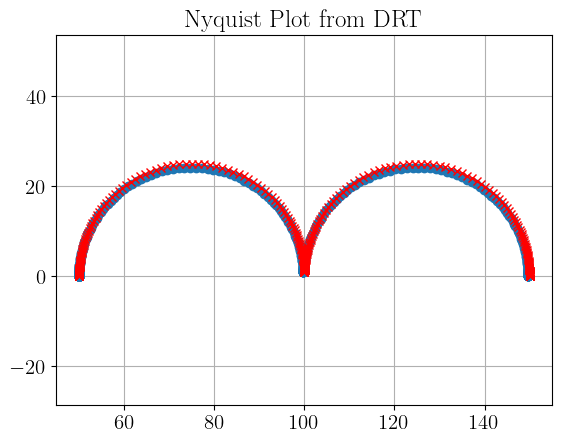

In [87]:
for file in mea['files']:
    freq_vec_old = [1,2]
    print(file)
#     print((n-n%3)/3)
#     file = s244['files'][int((n-n%3)/3)]
    # file = s244['files'][n]
    # skip_rows = get_header_lines(file)
    with open(file, encoding='latin1') as f:
        df = np.loadtxt(f,skiprows = 3,delimiter = '\t')
        
    # unique_vals = np.unique(df["cycle number"].values)
    # groups = [data[df["cycle number"].values == val] for val in unique_vals]
    
    # R_inf_DRT_list = []
    # L_0_DRT_list = []
    DRT_list = []
    # Z_DRT_list = [0]*len(unique_vals)
    # Z_exp_list = [0]*len(unique_vals)
    Z_exp_list = []
    freq_list = []
    log_tau_list = []
    lambda_value = 0.002
    rows = []
    
    # for val in unique_vals:
    freq_vec = np.flip(df[:,0])
    Z_exp = df[:,1] + 1j*df[:,2]
    Z_exp = np.flip(Z_exp)
    
    # print(freq_vec)
    # print(Z_exp)
        # I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        # E = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
        # if np.diff(freq_vec).any() <  0:
            # print('problem')
        # else:
            # pass


    mask = (freq_vec > 0) & (freq_vec <= 2e8)
    mask &= np.isfinite(Z_exp.real) & np.isfinite(Z_exp.imag)


    freq_vec = freq_vec[mask]
    Z_exp = Z_exp[mask]
    # freq_vec_old = freq_vec

    if list(freq_vec) == list(freq_vec_old):
        pass
    else:
        freq_vec_old = freq_vec

        N_freqs = len(freq_vec)
        N_taus = N_freqs

        log_tau_min = round(np.log10(6.28/max(freq_vec)),3)  
        log_tau_max = round(np.log10(6.28/min(freq_vec)),3)   
        # tau_vec = np.logspace(log_tau_min, log_tau_max, num = N_taus, endpoint=True)
        tau_vec = 1/freq_vec
        log_tau_vec = np.log(tau_vec)
        log_tau_list.append(log_tau_vec)

        # print(log_tau_min,log_tau_max)

        epsilon  = basics.compute_epsilon(freq_vec, coeff, rbf_type, shape_control)

        # step 3: compute the differentiation matrices
        A_re = basics.assemble_A_re(freq_vec, tau_vec, epsilon, rbf_type)
        A_re_R_inf = np.ones((N_freqs, 1))
        A_re_L_0 = np.zeros((N_freqs, 1))
        A_re = np.hstack(( A_re_R_inf, A_re_L_0, A_re))
        A_im = basics.assemble_A_im(freq_vec, tau_vec, epsilon, rbf_type)
        A_im_R_inf = np.zeros((N_freqs, 1))
        A_im_L_0 = 2*np.pi*freq_vec.reshape((N_freqs, 1))
        A_im = np.hstack(( A_im_R_inf, A_im_L_0, A_im))
        A = np.vstack((A_re, A_im))

        # step 4: compute the differentiation matrix
        M2 = np.zeros((N_taus+2, N_taus+2))
        M2[2:,2:] = basics.assemble_M_1(tau_vec, epsilon, rbf_type)


    # step 5: compute the regularization parameter
    # lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, -3, 'GCV')


    # lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp),  M2,'both',    'yes',     # no inductive part handling
    # -3,       # starting log10(lambda) (the code will scan from here)
    # 'GCV'     # generalized cross-validation
    #     )


    lambda_value = [0.002]
    # print('lambda', lambda_value)
    # step 6: recover the DRT
    ### 
    lb = np.zeros([N_taus+2])
    bound_mat = np.eye(lb.shape[0])
    H_combined, c_combined = basics.quad_format_combined(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, lambda_value)

    # set bound constraint
    G = matrix(-np.identity(Z_exp.imag.shape[0]+2))


    h = matrix(np.zeros(Z_exp.imag.shape[0]+2))



    sol = solvers.qp(matrix(H_combined), matrix(c_combined),G,h)
    ## deconvolved DRT
    x = np.array(sol['x']).flatten()

    # R_inf_DRT_list.append(x[0])
    # L_0_DRT_list.append(x[1])


    DRT_list.append(np.concatenate(([lambda_value[0]],x)))

    for f,g in zip(freq_vec,x[2:]):
        rows.append([f,g,x[0],x[1],lambda_value[0]])
        # print([val,f,g,x[0],x[1]])




    # plt.plot(freq_vec,x[2:])


    tau = 6.28/freq_vec       # s

    Z = drt_to_impedance(tau, 2.12*x[2:], freq_vec, R_inf=x[0], L=x[1])
    # print(mea['L'][52+x])

    # Nyquist plot
    plt.figure()
    plt.plot(Z.real, -Z.imag, 'o-')
    plt.plot(Z_exp.real, -Z_exp.imag, 'x', c = 'red')

    # plt.xlabel("Z' (Ω)")
    # plt.ylabel("-Z'' (Ω)")
    plt.title("Nyquist Plot from DRT")
    plt.axis('equal')
    plt.grid(True)
    # plt.title(str(x+1))
    plt.show()

            
            
            
            
    # plt.xscale('log')
    # plt.show()
    newpath = mea['folder']+'PROCESSED_EIS/'
    if not os.path.exists(newpath):
        os.makedirs(newpath)    
        

    header = 'freq/Hz\tgamma\tR0/Ohm\tL/H\tlambda\t<Ewe>/V\t<I>/mA'    
    np.savetxt(mea['folder']+'ourDRT/'+'spectrum3.txt', rows, delimiter='\t',header = header, comments='')



50.382229275706415
-23.828516874197064


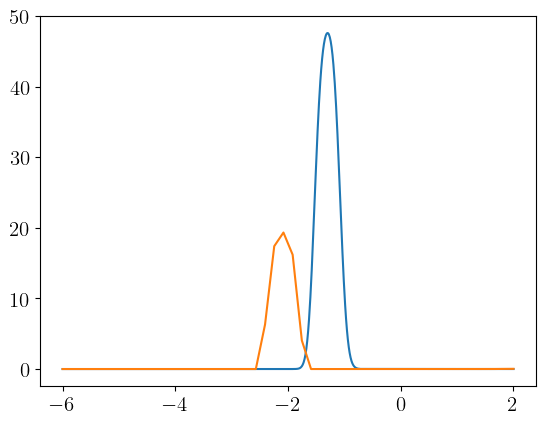

100.5477482549756
-47.28043772007402


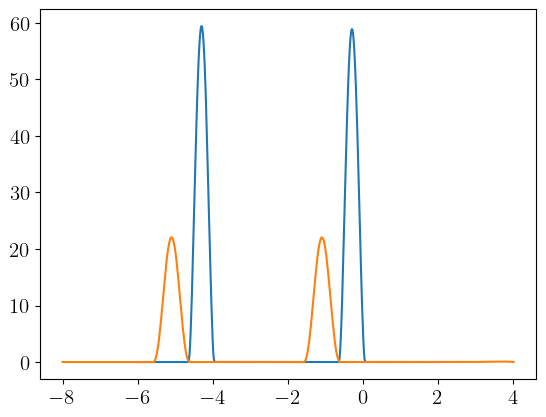

100.22674849217616
-47.15415378221401


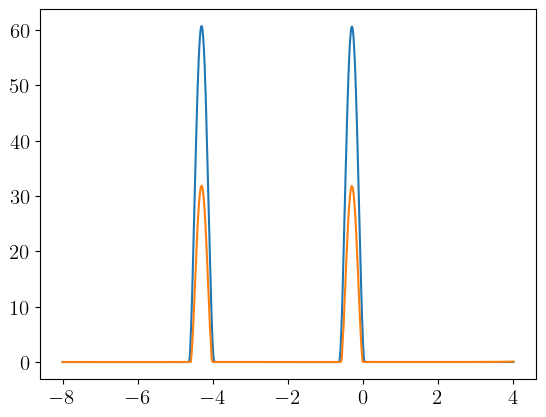

In [90]:
files = glob(os.path.join(mea['folder']+'relaxisDRT/','*.txt'))
# from scipy.integrate import quad
DRTr_files = glob(os.path.join(mea['folder']+'relaxisDRT/','*.txt'))
DRTo_files = glob(os.path.join(mea['folder']+'ourDRT/','*.txt'))

for i,file in enumerate(files):
    DRTr = np.loadtxt(DRTr_files[i],skiprows = 1)
    DRTo = np.loadtxt(DRTo_files[i],skiprows = 1)
    # print(DRTo)
    
    fr = DRTr[:,2]
    fo = DRTo[:,0]
    gr = DRTr[:,3]
    go = DRTo[:,1]
    
    print(np.trapz(gr, np.log(fr)))
    print(np.trapz(go, np.log(fo)))
    # print(quad(gr, 1e-6, 1e4))
    
    plt.plot(np.log10(1/fr),gr)
    plt.plot(np.log10(1/fo),go)
    # plt.xscale('log')
    plt.show()
   